# Plasmid-borne AMR across One Health compartments and mobility classes

The Phase-3 analysis behind the manuscript **_Mobility rivals provenance: plasmid-borne antimicrobial
resistance across One Health compartments_** (`manuscript/amr_onehealth_NAR.md`, target venue NAR).
It stratifies the CARD/RGI resistome (`card_*` columns, Perfect+Strict) of the 208,248-plasmid working
set by a **One Health compartment** crossed with **MOB-suite mobility**.

**Compartments are built from `hab_sub` + `is_clinical`, never `hab_top`.** `hab_top`'s
"Host-associated" level collapses human, livestock, plant and insect into one bucket, which destroys
the human / animal / environment structure a One Health analysis needs. `hab_top` is used only to honour
the locked exclusion of the Simulated- and Lab-artifact buckets (`reports/environment_taxonomy_LOCKED.md`),
and that exclusion is expressed here over `hab_sub`. Compartments assign **104,169 plasmids (50.0%)**;
the rest carry no curated habitat and are excluded from every compartment view.

**Headline results.** Resistance prevalence spans **24-fold**, from **44.6%** in the human-clinical
compartment to **1.8%** in wildlife (livestock/poultry second at 38.9%). Mobility is an axis of
comparable magnitude — **conjugative 60.1%** vs **non-mobilizable 6.7%** — and the ordering is monotonic
within every compartment. After adjusting for plasmid size and GC, both axes survive, and some
univariate compartment gaps (plant/food, wildlife) turn out to be size/mobility-composition artefacts.

**Methods.** Wilson 95% CIs for prevalences; χ² with Cramér's *V*; pairwise Fisher vs the natural-
environment baseline with Benjamini–Hochberg FDR; logistic regression of AMR status on
compartment + mobility + log₁₀(size) + GC (references: natural environment / non-mobilizable); Jaccard
over ARO sets; and a clonal-redundancy check redrawing one plasmid per MOB cluster under a fixed seed.

**Provenance.** Built by `scripts/build_onehealth_notebook.py` from
`scripts/analyze_amr_onehealth_mobility.py` (§1–§8) and `scripts/reassess_review_findings.py`
(round-1 review reassessment, R1–R8). CARD v4.0.1 / RGI 6.0.8; see `reports/card_amr_methodology.md`.

## 0 · Setup — data, compartment map, and helpers

In [1]:
%matplotlib inline
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint

# run from the project root regardless of where the kernel started
while not Path("data/plasmidscope_primary/plasmid_metadata_master.tsv").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "figure.facecolor": "white", "font.size": 9})

PP = "data/plasmidscope_primary"
MASTER = f"{PP}/plasmid_metadata_master.tsv"
FIGDIR = Path("reports/figures/onehealth"); FIGDIR.mkdir(parents=True, exist_ok=True)
SEED = 20260727

In [2]:
# hab_sub -> (One Health domain, compartment). Human sub-habitats split by is_clinical at runtime;
# anything absent from this map carries no compartment and is excluded.
HUMAN_SUBS = {
    "Human: unspecified", "Human: gut/faeces", "Human: blood", "Human: urine",
    "Human: respiratory", "Human: skin/wound", "Human: other clinical", "Human: oral",
}
COMPARTMENT_MAP = {
    "Livestock: pig": ("Animal", "Animal - livestock & poultry"),
    "Livestock: cattle": ("Animal", "Animal - livestock & poultry"),
    "Livestock: other": ("Animal", "Animal - livestock & poultry"),
    "Poultry/bird": ("Animal", "Animal - livestock & poultry"),
    "Companion animal": ("Animal", "Animal - companion & aquaculture"),
    "Fish/aquaculture": ("Animal", "Animal - companion & aquaculture"),
    "Other mammal": ("Animal", "Animal - wildlife & other"),
    "Rodent": ("Animal", "Animal - wildlife & other"),
    "Insect/arthropod": ("Animal", "Animal - wildlife & other"),
    "Other invertebrate": ("Animal", "Animal - wildlife & other"),
    "Gut/faeces: unspecified host": ("Animal", "Animal - wildlife & other"),
    "Wastewater/sewage": ("Environment", "Environment - engineered interface"),
    "Bioreactor": ("Environment", "Environment - engineered interface"),
    "Built environment": ("Environment", "Environment - engineered interface"),
    "Solid waste/compost": ("Environment", "Environment - engineered interface"),
    "Industrial/remediation": ("Environment", "Environment - engineered interface"),
    "Terrestrial/soil": ("Environment", "Environment - natural"),
    "Aquatic: freshwater/other": ("Environment", "Environment - natural"),
    "Aquatic: marine": ("Environment", "Environment - natural"),
    "Air": ("Environment", "Environment - natural"),
    "Extreme/other": ("Environment", "Environment - natural"),
    "Environmental: unspecified": ("Environment", "Environment - natural"),
    "Plant": ("Plant & food", "Plant & food"),
    "Food/fermentation": ("Plant & food", "Plant & food"),
    "Algae": ("Plant & food", "Plant & food"),
    "Fungi": ("Plant & food", "Plant & food"),
}
# Fixed display / model order; "Environment - natural" is the regression reference level.
ORDER = [
    "Human - clinical", "Human - community",
    "Animal - livestock & poultry", "Animal - companion & aquaculture",
    "Animal - wildlife & other",
    "Environment - engineered interface", "Environment - natural",
    "Plant & food",
]
REF = "Environment - natural"
MOB_ORDER = ["conjugative", "mobilizable", "non-mobilizable"]


def assign_compartment(row):
    sub = row["hab_sub"]
    if sub in HUMAN_SUBS:
        return "Human - clinical" if row["is_clinical"] == 1 else "Human - community"
    return COMPARTMENT_MAP.get(sub, (None, None))[1]


def assign_domain(row):
    sub = row["hab_sub"]
    if sub in HUMAN_SUBS:
        return "Human"
    return COMPARTMENT_MAP.get(sub, (None, None))[0]


def wilson(k, n):
    if n == 0:
        return (np.nan, np.nan)
    return proportion_confint(k, n, alpha=0.05, method="wilson")


def split_semi(s):
    "';'-joined list column -> set of non-empty items."
    if not isinstance(s, str) or not s:
        return set()
    return {x.strip() for x in s.split(";") if x.strip()}


def prevalence_table(df, group_col, order=None):
    rows = []
    groups = order if order is not None else sorted(df[group_col].dropna().unique())
    for g in groups:
        sub = df[df[group_col] == g]
        n = len(sub)
        if n == 0:
            continue
        k = int(sub.amr_pos.sum())
        km = int(sub.card_multidrug.sum())
        lo, hi = wilson(k, n)
        mlo, mhi = wilson(km, n)
        carriers = sub.loc[sub.amr_pos, "card_n_arg"]
        rows.append({
            group_col: g, "n": n,
            "amr_pos": k, "amr_prevalence": k / n, "amr_ci_lo": lo, "amr_ci_hi": hi,
            "multidrug": km, "multidrug_prevalence": km / n, "md_ci_lo": mlo, "md_ci_hi": mhi,
            "median_args_in_carriers": float(carriers.median()) if k else 0.0,
            "mean_args_in_carriers": float(carriers.mean()) if k else 0.0,
            "max_args": int(sub.card_n_arg.max()),
        })
    return pd.DataFrame(rows)


def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    return np.sqrt(chi2 / (n * (min(ct.shape) - 1)))

In [3]:
df = pd.read_csv(MASTER, sep="\t", low_memory=False)
df["amr_pos"] = df.card_n_arg > 0
df["compartment"] = df.apply(assign_compartment, axis=1)
df["oh_domain"] = df.apply(assign_domain, axis=1)

oh = df[df.compartment.notna()].copy()
oh["compartment"] = pd.Categorical(oh.compartment, categories=ORDER, ordered=True)
print(f"master:              {len(df):,} plasmids x {df.shape[1]} columns")
print(f"One Health set:      {len(oh):,} ({100*len(oh)/len(df):.1f}% of working set)")
print(f"excluded (no comp.): {len(df)-len(oh):,}")

master:              208,248 plasmids x 70 columns
One Health set:      104,169 (50.0% of working set)
excluded (no comp.): 104,079


## 1 · A 24-fold resistance gradient across One Health compartments

AMR / multidrug prevalence per compartment with Wilson 95% CIs, a global χ² with Cramér's *V*, and
pairwise Fisher tests against the natural-environment baseline (Benjamini–Hochberg FDR).
→ `onehealth_prevalence_by_compartment.tsv`, `onehealth_pairwise_vs_natural.tsv`. **(Paper Table 1.)**

In [4]:
comp_tab = prevalence_table(oh, "compartment", ORDER)
comp_tab.to_csv(f"{PP}/onehealth_prevalence_by_compartment.tsv", sep="\t", index=False)

ct = pd.crosstab(oh.compartment, oh.amr_pos)
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"chi2={chi2:,.1f}  dof={dof}  p={p:.3e}  Cramers_V={cramers_v(ct):.3f}")
comp_tab[["compartment", "n", "amr_pos", "amr_prevalence", "amr_ci_lo", "amr_ci_hi",
          "multidrug_prevalence", "median_args_in_carriers"]].round(4)

chi2=15,043.4  dof=7  p=0.000e+00  Cramers_V=0.380


,compartment,n,amr_pos,amr_prevalence,amr_ci_lo,amr_ci_hi,multidrug_prevalence,median_args_in_carriers
0,Human - clinical,18171,8111,0.4464,0.4392,0.4536,0.3635,4.0
1,Human - community,27766,5873,0.2115,0.2068,0.2164,0.1685,3.0
2,Animal - livestock & poultry,5041,1961,0.3890,0.3756,0.4025,0.3047,4.0
3,Animal - companion & aquaculture,1395,287,0.2057,0.1853,0.2277,0.1534,4.0
4,Animal - wildlife & other,7891,145,0.0184,0.0156,0.0216,0.0106,1.0
5,Environment - engineered interface,12028,1310,0.1089,0.1035,0.1146,0.0686,2.0
6,Environment - natural,24742,1016,0.0411,0.0387,0.0436,0.0247,1.0
7,Plant & food,7135,891,0.1249,0.1174,0.1328,0.0847,1.0


In [5]:
# pairwise vs the natural-environment baseline, BH-corrected
ref_sub = oh[oh.compartment == REF]
rows = []
for g in ORDER:
    if g == REF:
        continue
    s = oh[oh.compartment == g]
    table = [[int(s.amr_pos.sum()), len(s) - int(s.amr_pos.sum())],
             [int(ref_sub.amr_pos.sum()), len(ref_sub) - int(ref_sub.amr_pos.sum())]]
    orv, pv = stats.fisher_exact(table)
    rows.append({"compartment": g, "vs": REF, "odds_ratio": orv, "p_raw": pv})
pw = pd.DataFrame(rows)
pw["p_bh"] = multipletests(pw.p_raw, method="fdr_bh")[1]
pw.to_csv(f"{PP}/onehealth_pairwise_vs_natural.tsv", sep="\t", index=False)
pw.round(4)

,compartment,vs,odds_ratio,p_raw,p_bh
0,Human - clinical,Environment - natural,18.8281,0.0,0.0
1,Human - community,Environment - natural,6.2645,0.0,0.0
2,Animal - livestock & poultry,Environment - natural,14.8682,0.0,0.0
3,Animal - companion & aquaculture,Environment - natural,6.0489,0.0,0.0
4,Animal - wildlife & other,Environment - natural,0.4371,0.0,0.0
5,Environment - engineered interface,Environment - natural,2.8542,0.0,0.0
6,Plant & food,Environment - natural,3.3323,0.0,0.0


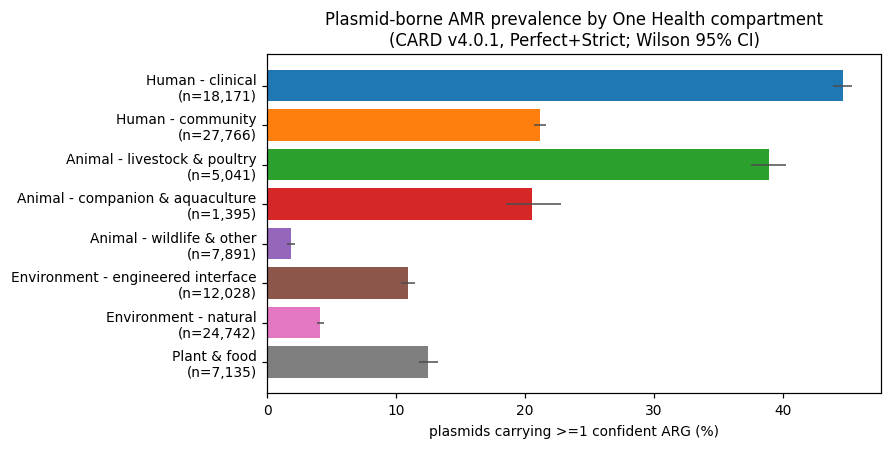

In [6]:
# Figure 1 — prevalence by compartment (Wilson 95% CI)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, ax = plt.subplots(figsize=(7.2, 4))
y = np.arange(len(comp_tab))
ax.barh(y, comp_tab.amr_prevalence * 100, color=colors[:len(comp_tab)],
        xerr=[(comp_tab.amr_prevalence - comp_tab.amr_ci_lo) * 100,
              (comp_tab.amr_ci_hi - comp_tab.amr_prevalence) * 100],
        error_kw={"ecolor": "0.3", "lw": 1})
ax.set_yticks(y)
ax.set_yticklabels([f"{c}\n(n={n:,})" for c, n in zip(comp_tab.compartment, comp_tab.n)])
ax.invert_yaxis()
ax.set_xlabel("plasmids carrying >=1 confident ARG (%)")
ax.set_title("Plasmid-borne AMR prevalence by One Health compartment\n"
             "(CARD v4.0.1, Perfect+Strict; Wilson 95% CI)")
fig.savefig(f"{FIGDIR}/amr_prevalence_by_compartment.png")
plt.show()

## 2 · Mobility is an axis of comparable magnitude

AMR / multidrug prevalence by MOB-suite mobility class. → `onehealth_prevalence_by_mobility.tsv`.
**(Paper Table 2.)**

In [7]:
mob = oh[oh.mob_mobility.notna()].copy()
mob_tab = prevalence_table(mob, "mob_mobility", MOB_ORDER)
mob_tab.to_csv(f"{PP}/onehealth_prevalence_by_mobility.tsv", sep="\t", index=False)
mob_tab[["mob_mobility", "n", "amr_pos", "amr_prevalence", "amr_ci_lo", "amr_ci_hi",
         "multidrug_prevalence"]].round(4)

,mob_mobility,n,amr_pos,amr_prevalence,amr_ci_lo,amr_ci_hi,multidrug_prevalence
0,conjugative,17965,10792,0.6007,0.5935,0.6079,0.5183
1,mobilizable,24677,4655,0.1886,0.1838,0.1936,0.1194
2,non-mobilizable,61526,4147,0.0674,0.0654,0.0694,0.0471


## 3 · The mobility ordering holds inside every compartment

Compartment × mobility joint prevalence — a Simpson's-paradox check. The conjugative > mobilizable >
non-mobilizable ordering is monotonic in every compartment. → `onehealth_compartment_x_mobility.tsv`.
**(Paper Figure 2.)**

In [8]:
joint = (mob.groupby(["compartment", "mob_mobility"], observed=True)
            .agg(n=("amr_pos", "size"), amr_pos=("amr_pos", "sum")).reset_index())
joint["amr_prevalence"] = joint.amr_pos / joint.n
joint.to_csv(f"{PP}/onehealth_compartment_x_mobility.tsv", sep="\t", index=False)
pivot = joint.pivot(index="compartment", columns="mob_mobility",
                    values="amr_prevalence").reindex(index=ORDER, columns=MOB_ORDER)
npivot = joint.pivot(index="compartment", columns="mob_mobility",
                     values="n").reindex(index=ORDER, columns=MOB_ORDER)
(pivot * 100).round(1)

mob_mobility,conjugative,mobilizable,non-mobilizable
compartment,,,
Human - clinical,73.6,35.2,23.9
Human - community,67.1,13.5,8.8
Animal - livestock & poultry,59.5,26.8,23.5
Animal - companion & aquaculture,55.6,16.9,9.4
Animal - wildlife & other,38.1,3.5,0.7
Environment - engineered interface,44.3,15.6,3.9
Environment - natural,27.4,9.0,2.0
Plant & food,24.7,15.2,6.7


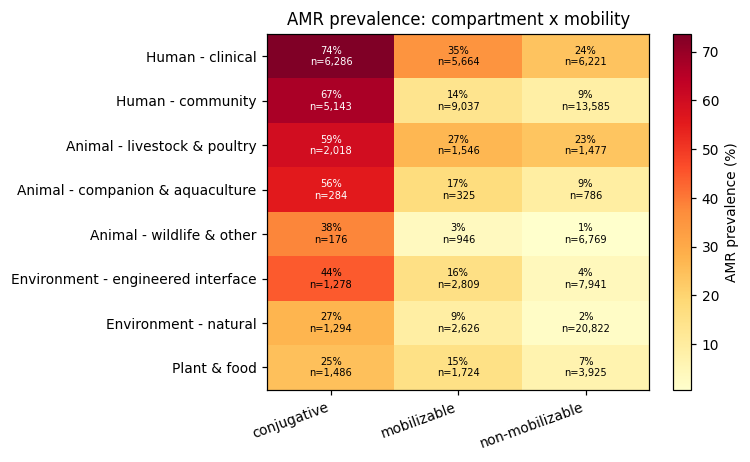

In [9]:
# Figure 2 — compartment x mobility heatmap
fig, ax = plt.subplots(figsize=(5.6, 4.2))
im = ax.imshow(pivot.values * 100, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(MOB_ORDER))); ax.set_xticklabels(MOB_ORDER, rotation=20, ha="right")
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER)
for i in range(len(ORDER)):
    for j in range(len(MOB_ORDER)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val*100:.0f}%\nn={int(npivot.values[i,j]):,}", ha="center",
                    va="center", fontsize=6.5, color="white" if val > 0.45 else "black")
fig.colorbar(im, ax=ax, label="AMR prevalence (%)")
ax.set_title("AMR prevalence: compartment x mobility")
fig.savefig(f"{FIGDIR}/amr_compartment_x_mobility.png")
plt.show()

## 4 · Adjustment separates genuine compartment effects from composition

Logistic regression of AMR status on compartment + mobility + log₁₀(size) + GC, references natural
environment / non-mobilizable. Odds ratios with 95% CIs. → `onehealth_logit_odds_ratios.tsv`.
**(Paper Figure 3.)**

In [10]:
reg = mob[mob.size_bp > 0].copy()
reg["amr_pos"] = reg.amr_pos.astype(int)   # statsmodels reads bool endog as categorical
reg["log_size"] = np.log10(reg.size_bp)
reg["comp"] = reg.compartment.astype(str)
reg["mobc"] = reg.mob_mobility.astype(str)
model = smf.logit(
    f'amr_pos ~ C(comp, Treatment(reference="{REF}")) '
    f'+ C(mobc, Treatment(reference="non-mobilizable")) + log_size + gc_percent',
    data=reg).fit(disp=0)
res = pd.DataFrame({"term": model.params.index, "coef": model.params.values, "p": model.pvalues.values})
ci = model.conf_int()
res["or"] = np.exp(res.coef); res["or_lo"] = np.exp(ci[0].values); res["or_hi"] = np.exp(ci[1].values)
res.to_csv(f"{PP}/onehealth_logit_odds_ratios.tsv", sep="\t", index=False)
print(f"n={len(reg):,}  pseudo-R2={model.prsquared:.3f}")
res[["term", "or", "or_lo", "or_hi", "p"]].round(4)

n=104,168  pseudo-R2=0.360


,term,or,or_lo,or_hi,p
0,Intercept,0.0000,0.0000,0.0000,0.0000
1,"C(comp, Treatment(reference=""Environment - nat...",2.5061,2.1376,2.9381,0.0000
2,"C(comp, Treatment(reference=""Environment - nat...",5.9229,5.3748,6.5268,0.0000
3,"C(comp, Treatment(reference=""Environment - nat...",0.8495,0.7059,1.0223,0.0842
4,"C(comp, Treatment(reference=""Environment - nat...",2.9381,2.6716,3.2312,0.0000
5,"C(comp, Treatment(reference=""Environment - nat...",8.9368,8.2685,9.6591,0.0000
6,"C(comp, Treatment(reference=""Environment - nat...",4.9939,4.6185,5.3997,0.0000
7,"C(comp, Treatment(reference=""Environment - nat...",1.0926,0.9841,1.2129,0.0969
8,"C(mobc, Treatment(reference=""non-mobilizable"")...",4.7740,4.5385,5.0217,0.0000
9,"C(mobc, Treatment(reference=""non-mobilizable"")...",2.7666,2.6287,2.9117,0.0000


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.


findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.


...

findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


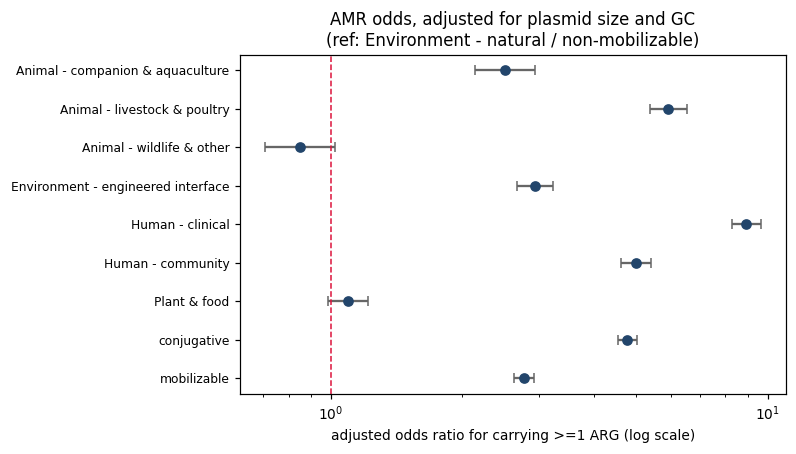

In [11]:
# Figure 3 — adjusted odds-ratio forest plot
plot_terms = res[res.term.str.contains(r"C\(comp|C\(mobc")].copy()
plot_terms["label"] = (plot_terms.term.str.replace(r".*\[T\.", "", regex=True)
                                 .str.replace(r"\]$", "", regex=True))
fig, ax = plt.subplots(figsize=(6.4, 4))
yy = np.arange(len(plot_terms))
ax.errorbar(plot_terms["or"], yy,
            xerr=[plot_terms["or"] - plot_terms.or_lo, plot_terms.or_hi - plot_terms["or"]],
            fmt="o", color="#22456b", ecolor="0.4", capsize=3)
ax.axvline(1, color="crimson", ls="--", lw=1)
ax.set_yticks(yy); ax.set_yticklabels(plot_terms.label, fontsize=8)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("adjusted odds ratio for carrying >=1 ARG (log scale)")
ax.set_title(f"AMR odds, adjusted for plasmid size and GC\n(ref: {REF} / non-mobilizable)")
fig.savefig(f"{FIGDIR}/amr_adjusted_odds_ratios.png")
plt.show()

## 5 · Compartment-specific drug-class signatures

Drug-class spectrum of the resistome per compartment (fraction of that compartment's AMR+ carriers
carrying each class), top-15 classes. → `onehealth_drug_class_by_compartment.tsv`. **(Paper Figure 4.)**

In [12]:
pos = oh[oh.amr_pos].copy()
dc_rows = []
for g in ORDER:
    s = pos[pos.compartment == g]
    if len(s) == 0:
        continue
    counter = {}
    for v in s.card_drug_classes:
        for c in split_semi(v):
            counter[c] = counter.get(c, 0) + 1
    for c, k in counter.items():
        dc_rows.append({"compartment": g, "drug_class": c, "n_plasmids": k, "frac_of_carriers": k / len(s)})
dc = pd.DataFrame(dc_rows)
dc.to_csv(f"{PP}/onehealth_drug_class_by_compartment.tsv", sep="\t", index=False)
top_classes = (dc.groupby("drug_class").n_plasmids.sum().sort_values(ascending=False).head(15).index.tolist())
dc_pivot = (dc[dc.drug_class.isin(top_classes)]
            .pivot(index="drug_class", columns="compartment", values="frac_of_carriers")
            .reindex(index=top_classes, columns=ORDER))
(dc_pivot * 100).round(1)

compartment,Human - clinical,Human - community,Animal - livestock & poultry,Animal - companion & aquaculture,Animal - wildlife & other,Environment - engineered interface,Environment - natural,Plant & food
drug_class,,,,,,,,
penicillin beta-lactam,65.6,59.5,39.2,43.9,35.2,46.2,31.3,24.8
cephalosporin,58.2,58.1,48.1,51.9,40.7,47.6,34.0,29.6
aminoglycoside antibiotic,56.7,52.9,58.5,57.5,35.9,45.6,30.2,32.8
sulfonamide antibiotic,38.8,39.1,41.8,48.1,28.3,37.3,24.9,19.5
tetracycline antibiotic,24.3,29.9,52.8,42.5,35.2,31.8,30.0,52.5
disinfecting agents and antiseptics,30.0,29.5,28.4,34.1,24.8,43.7,32.1,18.0
monobactam,32.5,31.4,24.0,24.4,22.1,25.7,17.6,14.7
diaminopyrimidine antibiotic,28.8,29.1,28.5,30.3,20.7,25.7,15.7,15.4
carbapenem,32.6,32.7,11.0,13.2,11.7,18.3,13.6,5.1


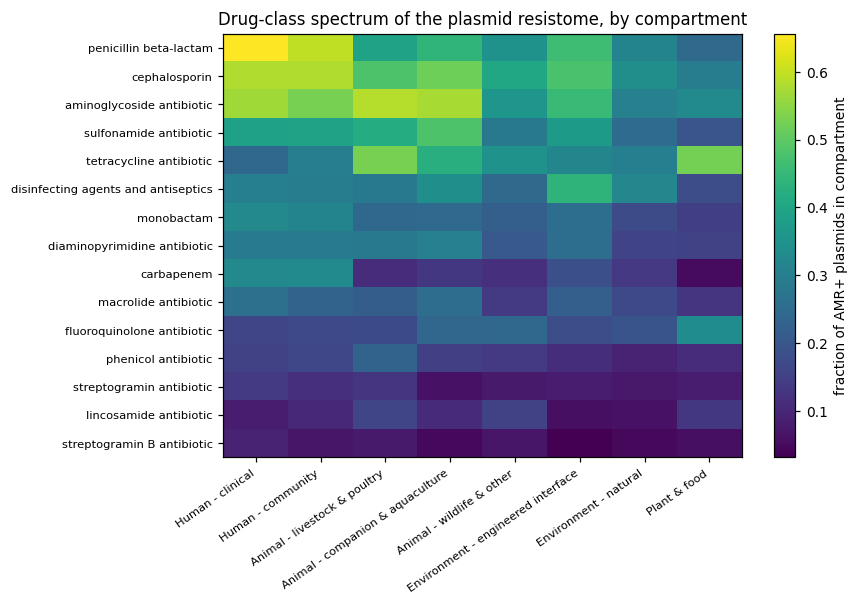

In [13]:
# Figure 4 — drug-class spectrum heatmap
fig, ax = plt.subplots(figsize=(7.6, 5))
im = ax.imshow(dc_pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=35, ha="right", fontsize=7.5)
ax.set_yticks(range(len(dc_pivot))); ax.set_yticklabels(dc_pivot.index, fontsize=7.5)
fig.colorbar(im, ax=ax, label="fraction of AMR+ plasmids in compartment")
ax.set_title("Drug-class spectrum of the plasmid resistome, by compartment")
fig.savefig(f"{FIGDIR}/drug_class_by_compartment.png")
plt.show()

## 6 · Resistance repertoires form a human block and an agricultural–environmental block

Cross-compartment sharing of ARG repertoires: Jaccard index over the sets of distinct ARO accessions,
plus unique-ARO richness per compartment. → `onehealth_arg_jaccard.tsv`, `onehealth_arg_richness.tsv`.
**(Paper Figure 5.)**

In [14]:
aro_sets = {}
for g in ORDER:
    s = pos[pos.compartment == g]
    acc = set()
    for v in s.card_aro_list:
        acc |= split_semi(v)
    aro_sets[g] = acc
jac = pd.DataFrame(index=ORDER, columns=ORDER, dtype=float)
for a in ORDER:
    for b in ORDER:
        ua, ub = aro_sets[a], aro_sets[b]
        jac.loc[a, b] = len(ua & ub) / len(ua | ub) if (ua | ub) else np.nan
jac.to_csv(f"{PP}/onehealth_arg_jaccard.tsv", sep="\t")
rich = pd.DataFrame({"compartment": ORDER,
                     "n_carriers": [int((pos.compartment == g).sum()) for g in ORDER],
                     "n_unique_aro": [len(aro_sets[g]) for g in ORDER]})
rich.to_csv(f"{PP}/onehealth_arg_richness.tsv", sep="\t", index=False)
display(rich)
jac.round(3)

,compartment,n_carriers,n_unique_aro
0,Human - clinical,8111,686
1,Human - community,5873,623
2,Animal - livestock & poultry,1961,303
3,Animal - companion & aquaculture,287,165
4,Animal - wildlife & other,145,109
5,Environment - engineered interface,1310,327
6,Environment - natural,1016,310
7,Plant & food,891,236


,Human - clinical,Human - community,Animal - livestock & poultry,Animal - companion & aquaculture,Animal - wildlife & other,Environment - engineered interface,Environment - natural,Plant & food
Human - clinical,1.000,0.531,0.349,0.214,0.149,0.367,0.326,0.286
Human - community,0.531,1.000,0.370,0.241,0.164,0.381,0.341,0.298
Animal - livestock & poultry,0.349,0.370,1.000,0.385,0.288,0.422,0.436,0.473
Animal - companion & aquaculture,0.214,0.241,0.385,1.000,0.391,0.348,0.381,0.412
Animal - wildlife & other,0.149,0.164,0.288,0.391,1.000,0.279,0.293,0.358
Environment - engineered interface,0.367,0.381,0.422,0.348,0.279,1.000,0.438,0.408
Environment - natural,0.326,0.341,0.436,0.381,0.293,0.438,1.000,0.472
Plant & food,0.286,0.298,0.473,0.412,0.358,0.408,0.472,1.000


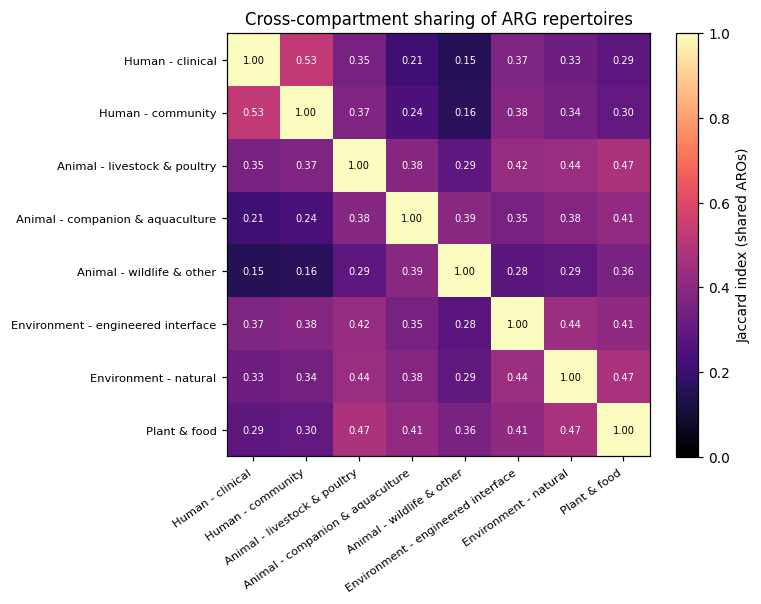

In [15]:
# Figure 5 — ARG-repertoire Jaccard heatmap
fig, ax = plt.subplots(figsize=(6.2, 5))
im = ax.imshow(jac.values.astype(float), cmap="magma", vmin=0, vmax=1)
ax.set_xticks(range(len(ORDER))); ax.set_xticklabels(ORDER, rotation=35, ha="right", fontsize=7.5)
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER, fontsize=7.5)
for i in range(len(ORDER)):
    for j in range(len(ORDER)):
        v_ = jac.values[i, j]
        if not np.isnan(v_):
            ax.text(j, i, f"{v_:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if v_ < 0.6 else "black")
fig.colorbar(im, ax=ax, label="Jaccard index (shared AROs)")
ax.set_title("Cross-compartment sharing of ARG repertoires")
fig.savefig(f"{FIGDIR}/arg_repertoire_jaccard.png")
plt.show()

## 7 · Multireplicon architecture and resistance outside the clinic

Within each compartment, does a multireplicon plasmid (PlasmidFinder ≥2 distinct Inc) carry AMR more
often than a single/none plasmid? Fisher per compartment, BH-corrected. → `onehealth_multireplicon_amr.tsv`.

In [16]:
mr = oh[oh.pf_n_inc.notna()].copy()
mr["multireplicon"] = mr.pf_n_inc >= 2
mr_rows = []
for g in ORDER:
    s = mr[mr.compartment == g]
    a = s[s.multireplicon]; b = s[~s.multireplicon]
    if len(a) == 0 or len(b) == 0:
        continue
    orv, pv = stats.fisher_exact(
        [[int(a.amr_pos.sum()), len(a) - int(a.amr_pos.sum())],
         [int(b.amr_pos.sum()), len(b) - int(b.amr_pos.sum())]])
    mr_rows.append({"compartment": g, "n_multireplicon": len(a),
                    "amr_prev_multireplicon": a.amr_pos.mean(), "n_single_or_none": len(b),
                    "amr_prev_other": b.amr_pos.mean(), "odds_ratio": orv, "p_raw": pv})
mrt = pd.DataFrame(mr_rows)
mrt["p_bh"] = multipletests(mrt.p_raw, method="fdr_bh")[1]
mrt.to_csv(f"{PP}/onehealth_multireplicon_amr.tsv", sep="\t", index=False)
mrt.round(4)

,compartment,n_multireplicon,amr_prev_multireplicon,n_single_or_none,amr_prev_other,odds_ratio,p_raw,p_bh
0,Human - clinical,4850,0.5538,13321,0.4073,1.8066,0.0,0.0
1,Human - community,4460,0.5101,23305,0.1544,5.7028,0.0,0.0
2,Animal - livestock & poultry,1157,0.5436,3884,0.3429,2.2824,0.0,0.0
3,Animal - companion & aquaculture,147,0.6190,1248,0.1571,8.7219,0.0,0.0
4,Animal - wildlife & other,266,0.1617,7625,0.0134,14.2218,0.0,0.0
5,Environment - engineered interface,1135,0.2749,10893,0.0916,3.7587,0.0,0.0
6,Environment - natural,643,0.3717,24099,0.0322,17.7567,0.0,0.0
7,Plant & food,501,0.4451,6634,0.1007,7.1642,0.0,0.0


## 8 · Clonal redundancy inflates absolute prevalence but preserves the gradient

Robustness check: redraw one plasmid at random per MOB cluster (fixed seed) and recompute prevalence.
Absolute prevalence roughly halves, but the compartment ordering is intact.
→ `onehealth_dereplication_sensitivity.tsv`. **(Paper Figure 6.)**

In [17]:
dedup = (oh[oh.mob_cluster.notna()].groupby("mob_cluster", observed=True).sample(n=1, random_state=SEED))
ded_tab = prevalence_table(dedup, "compartment", ORDER)[["compartment", "n", "amr_prevalence"]].rename(
    columns={"n": "n_dedup", "amr_prevalence": "amr_prevalence_dedup"})
comp_cmp = comp_tab[["compartment", "n", "amr_prevalence"]].merge(ded_tab, on="compartment", how="left")
comp_cmp.to_csv(f"{PP}/onehealth_dereplication_sensitivity.tsv", sep="\t", index=False)
print(f"one plasmid per MOB cluster: n={len(dedup):,}")
comp_cmp.round(4)

one plasmid per MOB cluster: n=6,182


,compartment,n,amr_prevalence,n_dedup,amr_prevalence_dedup
0,Human - clinical,18171,0.4464,739,0.2382
1,Human - community,27766,0.2115,963,0.1412
2,Animal - livestock & poultry,5041,0.3890,246,0.2195
3,Animal - companion & aquaculture,1395,0.2057,131,0.1527
4,Animal - wildlife & other,7891,0.0184,453,0.0088
5,Environment - engineered interface,12028,0.1089,724,0.0622
6,Environment - natural,24742,0.0411,2024,0.0346
7,Plant & food,7135,0.1249,902,0.0588


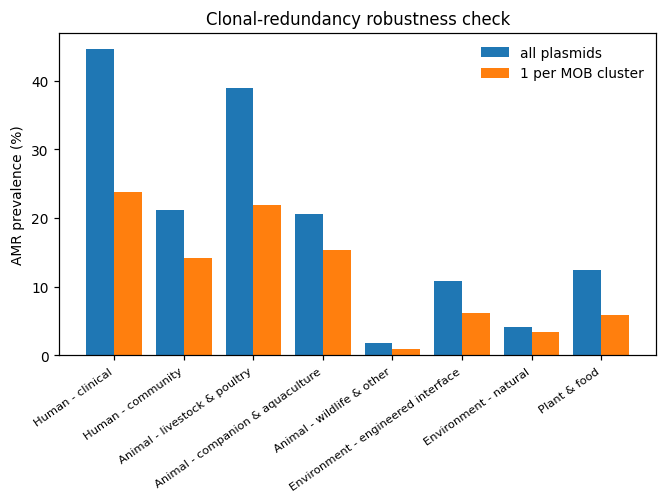

In [18]:
# Figure 6 — dereplication sensitivity
fig, ax = plt.subplots(figsize=(7, 3.8))
xx = np.arange(len(comp_cmp))
ax.bar(xx - 0.2, comp_cmp.amr_prevalence * 100, 0.4, label="all plasmids")
ax.bar(xx + 0.2, comp_cmp.amr_prevalence_dedup * 100, 0.4, label="1 per MOB cluster")
ax.set_xticks(xx); ax.set_xticklabels(comp_cmp.compartment, rotation=35, ha="right", fontsize=7.5)
ax.set_ylabel("AMR prevalence (%)"); ax.legend(frameon=False)
ax.set_title("Clonal-redundancy robustness check")
fig.savefig(f"{FIGDIR}/dereplication_sensitivity.png")
plt.show()

---
# Round-1 peer-review reassessment (R1–R8)

The computable items of the round-1 revision roadmap (`manuscript/review_round1.md`), reproduced from
`scripts/reassess_review_findings.py`. Host taxonomy is joined from PlasmidScope `all_metadata.tsv`
via the provenance representative key (the join used by `scripts/build_analysis_table.py`).

- **R1** host-taxon coverage per compartment (can the confounder even be tested?)
- **R2** collinearity — VIF + mobility-OR stability with/without log size
- **R3** cluster-robust SEs (groups = MOB cluster)
- **R4** compartment ORs before/after host-taxon adjustment
- **R5** adjusted headline contrast at matched size
- **R6** assignment bias — AMR in assigned vs unassigned plasmids
- **R7** PlasmidFinder typing coverage per compartment
- **R8** what the `is_clinical` flag rests on

→ `data/plasmidscope_primary/reassess_*.tsv`, `reports/figures/onehealth/reassess_compartment_or_shift.png`.

In [19]:
import csv, sys
csv.field_size_limit(sys.maxsize)

# Enterobacteriaceae (sensu lato) genera used for the detection-bias argument.
ENTERO = {
    "Escherichia", "Klebsiella", "Salmonella", "Enterobacter", "Citrobacter", "Serratia",
    "Proteus", "Shigella", "Cronobacter", "Providencia", "Morganella", "Yersinia",
    "Kluyvera", "Raoultella", "Leclercia", "Edwardsiella", "Hafnia", "Pluralibacter",
    "Lelliottia", "Atlantibacter", "Phytobacter", "Kosakonia",
}
NULL_HOST = {"-", "", "synthetic construct", "unclassified", "uncultured bacterium"}

# join PlasmidScope host taxonomy via the provenance representative key
rep2full = {}
with open(f"{PP}/complete_provenance.tsv", newline="") as fh:
    for r in csv.DictReader(fh, delimiter="\t"):
        rep2full[r["plasmid_id"].split(",")[0]] = r["plasmid_id"]
host = {}
with open(f"{PP}/all_metadata.tsv", newline="") as fh:
    for r in csv.DictReader(fh, delimiter="\t"):
        host[r["Plasmid_ID"]] = r.get("Host", "")
df["host_raw"] = df.plasmid_id.map(lambda p: host.get(rep2full.get(p, ""), "")).fillna("")
df["has_host"] = ~df.host_raw.str.strip().isin(NULL_HOST)
df["host_genus"] = np.where(df.has_host, df.host_raw.str.split().str[0], None)
df["is_entero"] = df.host_genus.isin(ENTERO).astype(int)

ohr = df[df.compartment.notna()].copy()

def or_table(m, label):
    ci = m.conf_int()
    out = pd.DataFrame({"term": m.params.index, "or": np.exp(m.params.values),
                        "or_lo": np.exp(ci[0].values), "or_hi": np.exp(ci[1].values), "p": m.pvalues.values})
    out["model"] = label
    out["k"] = out.term.str.replace(r".*\[T\.", "", regex=True).str.replace(r"\]$", "", regex=True)
    return out

print(f"working set {len(df):,}; One Health set {len(ohr):,}; with host taxonomy {int(df.has_host.sum()):,}")

working set 208,248; One Health set 104,169; with host taxonomy 96,230


### R1 · Host-taxonomy coverage by compartment → `reassess_host_coverage.tsv`

In [20]:
cov = (ohr.groupby("compartment").agg(n=("amr_pos", "size"), with_host=("has_host", "sum"),
                                      entero_frac=("is_entero", "mean")).reindex(ORDER))
cov["host_coverage"] = cov.with_host / cov.n
cov["entero_frac_of_hosted"] = ohr[ohr.has_host].groupby("compartment").is_entero.mean().reindex(ORDER)
cov.to_csv(f"{PP}/reassess_host_coverage.tsv", sep="\t")
cov[["n", "with_host", "host_coverage", "entero_frac_of_hosted"]].round(3)

,n,with_host,host_coverage,entero_frac_of_hosted
compartment,,,,
Human - clinical,18171,18030,0.992,0.666
Human - community,27766,14195,0.511,0.649
Animal - livestock & poultry,5041,4971,0.986,0.755
Animal - companion & aquaculture,1395,1326,0.951,0.291
Animal - wildlife & other,7891,1586,0.201,0.164
Environment - engineered interface,12028,3840,0.319,0.680
Environment - natural,24742,6340,0.256,0.178
Plant & food,7135,5001,0.701,0.152


### R6 · Assignment bias — AMR prevalence, assigned vs unassigned → `reassess_assignment_bias.tsv`

In [21]:
df["assigned"] = df.compartment.notna()
df["unassigned_kind"] = np.where(
    df.assigned, "assigned",
    np.where(df.hab_sub == "Simulated communities", "simulated",
             np.where(df.hab_sub.isin(["Unlabelled", "Geography only (no habitat)", "Unresolved"]),
                      "no label", "other excluded")))
ak = df.groupby("unassigned_kind").agg(n=("amr_pos", "size"), amr=("amr_pos", "sum"))
ak["prevalence"] = ak.amr / ak.n
ak.to_csv(f"{PP}/reassess_assignment_bias.tsv", sep="\t")
ak.round(4)

,n,amr,prevalence
unassigned_kind,,,
assigned,104169,19594,0.1881
no label,39331,7026,0.1786
other excluded,90,2,0.0222
simulated,64658,2774,0.0429


### R7 · PlasmidFinder typing coverage by compartment → `reassess_typing_coverage.tsv`

In [22]:
ohr["typed"] = (ohr.pf_n_inc.fillna(0) >= 1).astype(int)
tc = (ohr.groupby("compartment").agg(n=("typed", "size"), typed=("typed", "sum")).reindex(ORDER))
tc["typing_coverage"] = tc.typed / tc.n
tc.to_csv(f"{PP}/reassess_typing_coverage.tsv", sep="\t")
tc.round(3)

,n,typed,typing_coverage
compartment,,,
Human - clinical,18171,6926,0.381
Human - community,27766,7266,0.262
Animal - livestock & poultry,5041,1715,0.340
Animal - companion & aquaculture,1395,220,0.158
Animal - wildlife & other,7891,538,0.068
Environment - engineered interface,12028,2007,0.167
Environment - natural,24742,1053,0.043
Plant & food,7135,1120,0.157


### R8 · What the `is_clinical` flag rests on → `reassess_clinical_basis.tsv`

In [23]:
clin = ohr[ohr.compartment == "Human - clinical"]
body_site = clin.hab_sub.isin(["Human: blood", "Human: urine", "Human: respiratory",
                               "Human: skin/wound", "Human: other clinical"])
has_disease = clin.plsdb_disease_tags.notna() & (clin.plsdb_disease_tags != "")
basis = pd.DataFrame({
    "basis": ["clinical body site", "no body site, has PLSDB disease tag",
              "no body site, no disease tag (context only)"],
    "n": [int(body_site.sum()), int((~body_site & has_disease).sum()),
          int((~body_site & ~has_disease).sum())]})
basis["frac"] = basis.n / len(clin)
basis.to_csv(f"{PP}/reassess_clinical_basis.tsv", sep="\t", index=False)
basis.round(3)

,basis,n,frac
0,clinical body site,12614,0.694
1,"no body site, has PLSDB disease tag",4128,0.227
2,"no body site, no disease tag (context only)",1429,0.079


### Modelling set + R2 collinearity (VIF, mobility-OR stability) → `reassess_vif.tsv`

In [24]:
reg2 = ohr[ohr.mob_mobility.notna() & (ohr.size_bp > 0)].copy()
reg2["amr_pos"] = reg2.amr_pos.astype(int)   # statsmodels reads bool endog as categorical
reg2["log_size"] = np.log10(reg2.size_bp)
reg2["comp"] = reg2.compartment.astype(str)
reg2["mobc"] = reg2.mob_mobility.astype(str)
reg2["cluster"] = reg2.mob_cluster.fillna("NA")
BASE = (f'amr_pos ~ C(comp, Treatment(reference="{REF}")) '
        f'+ C(mobc, Treatment(reference="non-mobilizable")) + log_size + gc_percent')

from statsmodels.stats.outliers_influence import variance_inflation_factor
dm = pd.get_dummies(reg2[["comp", "mobc"]], drop_first=True).astype(float)
dm["log_size"] = reg2.log_size.values; dm["gc_percent"] = reg2.gc_percent.values
dm.insert(0, "const", 1.0)
vif = pd.DataFrame({"term": dm.columns,
                    "VIF": [variance_inflation_factor(dm.values, i) for i in range(dm.shape[1])]})
vif = vif[vif.term != "const"]
vif.to_csv(f"{PP}/reassess_vif.tsv", sep="\t", index=False)

m_full = smf.logit(BASE, data=reg2).fit(disp=0)
m_nosize = smf.logit(BASE.replace(" + log_size", ""), data=reg2).fit(disp=0)
print("mobility OR with vs without log_size in the model:")
for k in ["conjugative", "mobilizable"]:
    a = or_table(m_full, "with").set_index("k").loc[k]
    b = or_table(m_nosize, "without").set_index("k").loc[k]
    print(f"  {k:16s} with size OR={a['or']:.2f}   without size OR={b['or']:.2f}")
vif.sort_values("VIF", ascending=False).round(2)

mobility OR with vs without log_size in the model:
  conjugative      with size OR=4.77   without size OR=12.23
  mobilizable      with size OR=2.77   without size OR=2.02


,term,VIF
6,comp_Human - community,15.51
4,comp_Environment - natural,14.55
5,comp_Human - clinical,11.64
3,comp_Environment - engineered interface,8.66
2,comp_Animal - wildlife & other,6.30
7,comp_Plant & food,5.71
1,comp_Animal - livestock & poultry,4.42
9,mobc_non-mobilizable,2.79
8,mobc_mobilizable,2.38
10,log_size,1.62


### R3 · Cluster-robust standard errors (groups = MOB cluster) → `reassess_cluster_robust.tsv`

In [25]:
m_clu = smf.logit(BASE, data=reg2).fit(disp=0, cov_type="cluster", cov_kwds={"groups": reg2["cluster"]})
a = or_table(m_full, "nominal").set_index("k"); b = or_table(m_clu, "clustered").set_index("k")
cmp_rows = []
for k in a.index:
    if k == "Intercept":
        continue
    cmp_rows.append({
        "term": k, "or": round(a.loc[k, "or"], 3),
        "nominal_lo": round(a.loc[k, "or_lo"], 3), "nominal_hi": round(a.loc[k, "or_hi"], 3),
        "clustered_lo": round(b.loc[k, "or_lo"], 3), "clustered_hi": round(b.loc[k, "or_hi"], 3),
        "clustered_p": b.loc[k, "p"],
        "ci_width_ratio": round((b.loc[k, "or_hi"] - b.loc[k, "or_lo"]) / (a.loc[k, "or_hi"] - a.loc[k, "or_lo"]), 1),
        "still_sig_0.05": bool(b.loc[k, "p"] < 0.05)})
clu = pd.DataFrame(cmp_rows)
clu.to_csv(f"{PP}/reassess_cluster_robust.tsv", sep="\t", index=False)
print(f"n clusters = {reg2['cluster'].nunique():,}")
clu

n clusters = 6,182


,term,or,nominal_lo,nominal_hi,clustered_lo,clustered_hi,clustered_p,ci_width_ratio,still_sig_0.05
0,Animal - companion & aquaculture,2.506,2.138,2.938,1.691,3.713,4.671012e-06,2.5,True
1,Animal - livestock & poultry,5.923,5.375,6.527,4.013,8.741,3.338976e-19,4.1,True
2,Animal - wildlife & other,0.850,0.706,1.022,0.593,1.218,3.745791e-01,2.0,False
3,Environment - engineered interface,2.938,2.672,3.231,2.224,3.881,3.273449e-14,3.0,True
4,Human - clinical,8.937,8.269,9.659,6.335,12.607,9.995490e-36,4.5,True
5,Human - community,4.994,4.619,5.400,3.717,6.710,1.361753e-26,3.8,True
6,Plant & food,1.093,0.984,1.213,0.798,1.495,5.800999e-01,3.0,False
7,conjugative,4.774,4.539,5.022,3.304,6.898,8.475781e-17,7.4,True
8,mobilizable,2.767,2.629,2.912,1.835,4.170,1.173826e-06,8.3,True
9,log_size,4.894,4.710,5.086,3.544,6.760,5.447880e-22,8.6,True


### R4 · Compartment ORs before vs after host-taxon adjustment → `reassess_host_adjustment.tsv`

In [26]:
hs = reg2[reg2.has_host].copy()
top_genera = hs.host_genus.value_counts().head(20).index.tolist()
hs["genus_grp"] = np.where(hs.host_genus.isin(top_genera), hs.host_genus, "other")
m_h0 = smf.logit(BASE, data=hs).fit(disp=0)                                            # no host
m_h1 = smf.logit(BASE + " + is_entero", data=hs).fit(disp=0)                           # + Entero indicator
m_h2 = smf.logit(BASE + ' + C(genus_grp, Treatment(reference="other"))', data=hs).fit(disp=0)  # + top-20 genus
t0 = or_table(m_h0, "no host").set_index("k"); t1 = or_table(m_h1, "+entero").set_index("k")
t2 = or_table(m_h2, "+genus").set_index("k")
rows = []
for k in [c for c in ORDER if c != REF] + ["conjugative", "mobilizable", "log_size"]:
    if k not in t0.index:
        continue
    rows.append({"term": k, "OR_no_host": round(t0.loc[k, "or"], 2),
                 "OR_plus_entero": round(t1.loc[k, "or"], 2), "OR_plus_genus": round(t2.loc[k, "or"], 2),
                 "pct_change_genus": round(100 * (t2.loc[k, "or"] - t0.loc[k, "or"]) / t0.loc[k, "or"], 1),
                 "p_genus_model": t2.loc[k, "p"]})
host_cmp = pd.DataFrame(rows)
host_cmp.to_csv(f"{PP}/reassess_host_adjustment.tsv", sep="\t", index=False)
print(f"subset with host taxonomy: n={len(hs):,}   pseudo-R2: no host {m_h0.prsquared:.3f} | "
      f"+entero {m_h1.prsquared:.3f} | +genus {m_h2.prsquared:.3f}")
host_cmp

/gorilla/home/amujkic/.conda/envs/genesis/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/scratch/ipykernel_3270164/129116924.py:32: RuntimeWarning: overflow encountered in exp
  "or_lo": np.exp(ci[0].values), "or_hi": np.exp(ci[1].values), "p": m.pvalues.values})


subset with host taxonomy: n=55,288   pseudo-R2: no host 0.243 | +entero 0.252 | +genus 0.299


,term,OR_no_host,OR_plus_entero,OR_plus_genus,pct_change_genus,p_genus_model
0,Human - clinical,7.66,5.27,3.30,-56.9,5.362295e-118
1,Human - community,6.03,4.13,3.15,-47.8,6.161122e-106
2,Animal - livestock & poultry,5.22,3.38,2.85,-45.5,1.324451e-67
3,Animal - companion & aquaculture,2.26,1.92,2.26,0.1,6.512123e-20
4,Animal - wildlife & other,1.19,0.96,1.17,-1.8,2.195059e-01
5,Environment - engineered interface,2.99,2.16,1.61,-46.2,1.369597e-13
6,Plant & food,1.08,1.16,1.35,25.5,1.135555e-06
7,conjugative,4.22,3.51,3.38,-20.0,0.000000e+00
8,mobilizable,2.30,2.30,1.81,-21.1,9.448877e-83
9,log_size,3.89,4.18,4.33,11.5,0.000000e+00


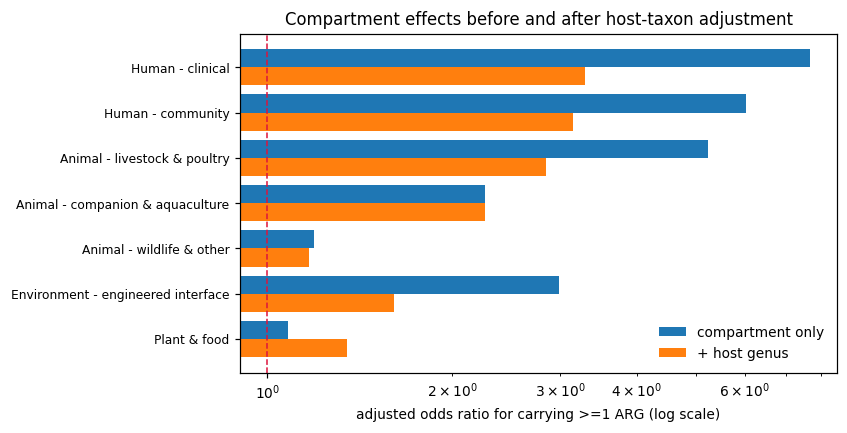

In [27]:
# Figure (supplementary) — compartment OR shift under host adjustment
plot = host_cmp[host_cmp.term.isin([c for c in ORDER if c != REF])]
fig, ax = plt.subplots(figsize=(7, 4))
y = np.arange(len(plot))
ax.barh(y - 0.2, plot.OR_no_host, 0.4, label="compartment only")
ax.barh(y + 0.2, plot.OR_plus_genus, 0.4, label="+ host genus")
ax.axvline(1, color="crimson", ls="--", lw=1)
ax.set_yticks(y); ax.set_yticklabels(plot.term, fontsize=8)
ax.invert_yaxis(); ax.set_xscale("log")
ax.set_xlabel("adjusted odds ratio for carrying >=1 ARG (log scale)")
ax.set_title("Compartment effects before and after host-taxon adjustment")
ax.legend(frameon=False)
fig.savefig(f"{FIGDIR}/reassess_compartment_or_shift.png")
plt.show()

### R5 · Adjusted headline contrast at matched plasmid size → `reassess_headline_contrast.tsv`

In [28]:
med_gc = float(reg2.gc_percent.median())
scen = []
for size_bp in [5000, 10000, 50000, 100000]:
    for comp_, mob_ in [("Environment - natural", "conjugative"),
                        ("Human - clinical", "non-mobilizable"),
                        ("Human - clinical", "conjugative"),
                        ("Environment - natural", "non-mobilizable")]:
        scen.append({"comp": comp_, "mobc": mob_, "log_size": np.log10(size_bp),
                     "gc_percent": med_gc, "size_bp": size_bp})
sc = pd.DataFrame(scen)
sc["pred_prob"] = m_full.predict(sc)
sc.to_csv(f"{PP}/reassess_headline_contrast.tsv", sep="\t", index=False)
piv = sc.pivot_table(index="size_bp", columns=["comp", "mobc"], values="pred_prob")

cell_a = reg2[(reg2.comp == "Environment - natural") & (reg2.mobc == "conjugative")]
cell_b = reg2[(reg2.comp == "Human - clinical") & (reg2.mobc == "non-mobilizable")]
print(f"env-natural/conjugative : n={len(cell_a):,} median={cell_a.size_bp.median():,.0f} bp  raw prev={cell_a.amr_pos.mean():.3f}")
print(f"clinical/non-mobilizable: n={len(cell_b):,} median={cell_b.size_bp.median():,.0f} bp  raw prev={cell_b.amr_pos.mean():.3f}")
print("\npredicted P(AMR+) at matched size, median GC (%):")
(piv * 100).round(1)

env-natural/conjugative : n=1,294 median=99,516 bp  raw prev=0.274
clinical/non-mobilizable: n=6,221 median=29,120 bp  raw prev=0.239

predicted P(AMR+) at matched size, median GC (%):


comp    Environment - natural                 Human - clinical                
mobc              conjugative non-mobilizable      conjugative non-mobilizable
size_bp                                                                       
5000                      4.1             0.9             27.7             7.4
10000                     6.5             1.4             38.2            11.5
50000                    17.3             4.2             65.2            28.2
100000                   25.3             6.6             75.1            38.8

---
*All result tables are written under `data/plasmidscope_primary/` (`onehealth_*.tsv`, `reassess_*.tsv`)
and the seven figures under `reports/figures/onehealth/`. Rebuild this notebook with
`python3 scripts/build_onehealth_notebook.py`; execute it with the **genesis_nb** kernel.*